SOP: 
Run code snippets, then scroll to bottom to find interactive annotation element.
1) Click on plot you are annotating (should be the first in the series that are loaded)
2) Select the object number you want to choose first (ex. "1" on keyboard)
3) Select the point until it is correct
4) Select the next object and continue selecting until all objects are selected
    Each object should appear with a different color point
5) Once all objects on a plot are finished, click "Enter" on keyboard to load next plot
6) As each plot is finished, results will be saved in selected_points.tsv

Future directions:
Load SAM image masking on selected objects to verify object can be accurately masked and labeled.

In [1]:
%matplotlib widget

In [12]:
import cv2
import os
import glob
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd
from matplotlib.widgets import Cursor



In [17]:
avi_dir = "/fs/vulcan-projects/fsh_track/data/autumn"  # change to data directory path
avi_files = sorted(glob.glob(os.path.join(avi_dir, "*.avi")))
output_data = []
output_file = "selected_points.tsv"

print(f"Found {len(avi_files)} AVI files.")

object_number = [None]
current_filename = [None]

# Holds the current object's point: {obj_number: (x, y)}
object_points = {}
# Holds the matplotlib artist objects for each point: {obj_number: artist}
object_artists = {}

Found 5 AVI files.


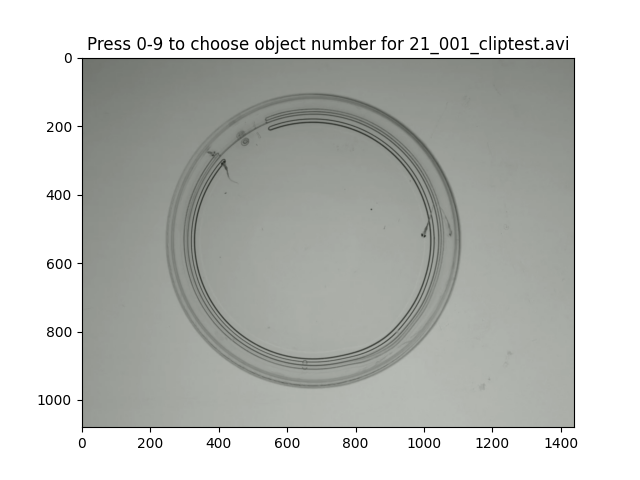

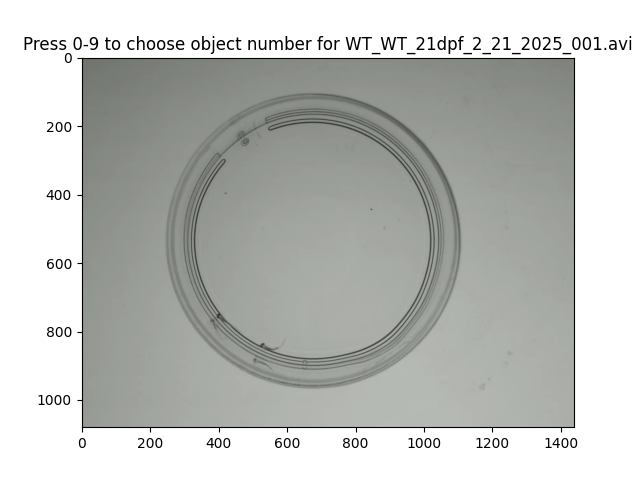

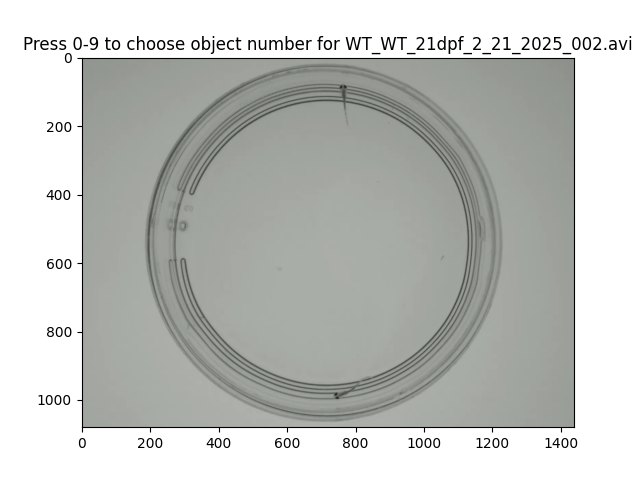

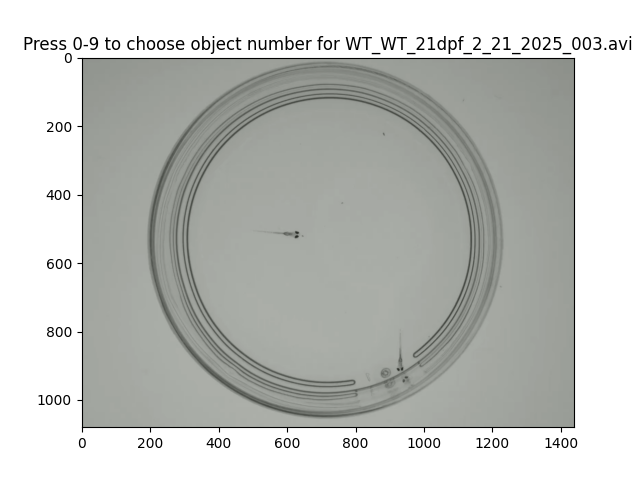

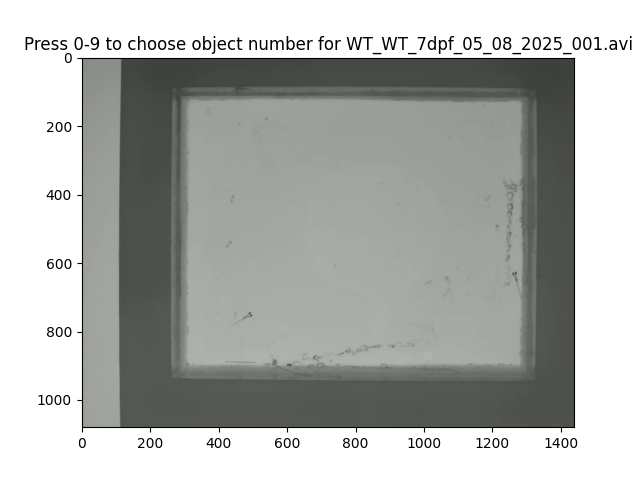

In [18]:
# Define 10 distinguishable colors
object_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'olive', 'cyan', 'magenta']

def on_key(event):
    if event.key.isdigit():
        obj_num = int(event.key)
        object_number[0] = obj_num
        ax.set_title(f"Selecting Object #{obj_num} on {os.path.basename(current_filename[0])}")
        fig.canvas.draw()
    elif event.key == 'enter':
        if object_points:
            for obj_num, (x, y) in object_points.items():
                output_data.append((current_filename[0], obj_num, x, y))
                print(f"✅ Saved: {current_filename[0]}, Object {obj_num}, X={x}, Y={y}")
            save_to_file()
        else:
            print("⚠️ No points selected for this frame.")
        fig.canvas.mpl_disconnect(cid_click[0])
        fig.canvas.mpl_disconnect(cid_key[0])
        plt.close(fig)
        next_video()

def on_click(event):
    if event.xdata is not None and event.ydata is not None and object_number[0] is not None:
        x, y = int(event.xdata), int(event.ydata)
        obj_num = object_number[0]
        object_points[obj_num] = (x, y)

        # Remove old artist if exists
        if obj_num in object_artists:
            object_artists[obj_num].remove()

        # Plot new point with its color
        artist = ax.plot(x, y, 'o', color=object_colors[obj_num], label=f"Obj {obj_num}")[0]
        object_artists[obj_num] = artist
        fig.canvas.draw()

def save_to_file():
    df = pd.DataFrame(output_data, columns=["filename", "object_number", "x", "y"])
    df.to_csv(output_file, sep="\t", index=False)

def next_video():
    if not avi_files:
        print("🎉 All videos processed!")
        return

    video_path = avi_files.pop(0)
    current_filename[0] = os.path.basename(video_path)
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"❌ Could not read from {video_path}")
        next_video()
        return

    global fig, ax, cid_click, cid_key
    fig, ax = plt.subplots()
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Press 0-9 to choose object number for {os.path.basename(video_path)}")
    Cursor(ax, useblit=True, color='gray', linewidth=1)

    # Clear current state
    object_points.clear()
    object_artists.clear()
    object_number[0] = None

    cid_click = [fig.canvas.mpl_connect('button_press_event', on_click)]
    cid_key = [fig.canvas.mpl_connect('key_press_event', on_key)]
    plt.show()

# Start the loop
next_video()